In [2]:
# Imports & setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('../results/cluster_plots', exist_ok=True)
os.makedirs('../results/pca_outputs',   exist_ok=True)
os.makedirs('../data/processed',        exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load processed data
df = pd.read_csv('../data/processed/customer_features.csv')

print(f"✅ Loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

✅ Loaded: (5878, 13)
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'TotalItems', 'AvgItemsPerOrder', 'UniqueProducts', 'NumCountries', 'CustomerAge', 'AvgDaysBetweenOrders', 'SpendPerItem', 'cancellation_rate']


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,TotalItems,AvgItemsPerOrder,UniqueProducts,NumCountries,CustomerAge,AvgDaysBetweenOrders,SpendPerItem,cancellation_rate
0,12346.0,326,12,29730.4202,363.127722,17491.68,2184.852941,27,1,726,60.50,1.044039,0.291667
1,12347.0,2,8,5633.3200,22.266087,3286.00,12.988142,126,1,404,50.50,1.714340,0.000000
2,12348.0,75,5,2019.4000,39.596078,2714.00,53.215686,25,1,438,87.60,0.744068,0.000000
3,12349.0,19,4,4428.6900,25.306800,1624.00,9.280000,138,1,589,147.25,2.727026,0.027778
4,12350.0,310,1,334.4000,19.670588,197.00,11.588235,17,1,310,310.00,1.697462,0.000000


In [3]:
# Select and isolate clustering features

# Customer ID is an identifier — exclude from clustering
customer_ids = df['Customer ID']

# These are the features we'll cluster on
FEATURES = [
    'Recency',
    'Frequency',
    'Monetary',
    'AvgOrderValue',
    'TotalItems',
    'AvgItemsPerOrder',
    'UniqueProducts',
    'CustomerAge',
    'AvgDaysBetweenOrders',
    'SpendPerItem',
    'cancellation_rate'
]

X = df[FEATURES].copy()

print(f"Features selected for clustering: {len(FEATURES)}")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2}. {f}")

print(f"\nShape of feature matrix: {X.shape}")
print(f"\nMissing values:\n{X.isnull().sum()}")

Features selected for clustering: 11
   1. Recency
   2. Frequency
   3. Monetary
   4. AvgOrderValue
   5. TotalItems
   6. AvgItemsPerOrder
   7. UniqueProducts
   8. CustomerAge
   9. AvgDaysBetweenOrders
  10. SpendPerItem
  11. cancellation_rate

Shape of feature matrix: (5878, 11)

Missing values:
Recency                 0
Frequency               0
Monetary                0
AvgOrderValue           0
TotalItems              0
AvgItemsPerOrder        0
UniqueProducts          0
CustomerAge             0
AvgDaysBetweenOrders    0
SpendPerItem            0
cancellation_rate       0
dtype: int64


Feature Skewness (before transformation)
  AvgItemsPerOrder                69.05  ⚠️  highly skewed
  SpendPerItem                    51.99  ⚠️  highly skewed
  UniqueProducts                   6.22  ⚠️  highly skewed
  cancellation_rate                5.32  ⚠️  highly skewed
  AvgOrderValue                    5.11  ⚠️  highly skewed
  TotalItems                       4.16  ⚠️  highly skewed
  Monetary                         4.10  ⚠️  highly skewed
  Frequency                        3.02  ⚠️  highly skewed
  AvgDaysBetweenOrders             1.44  ⚠️  highly skewed
  Recency                          0.88  📊 moderate
  CustomerAge                     -0.62  📊 moderate


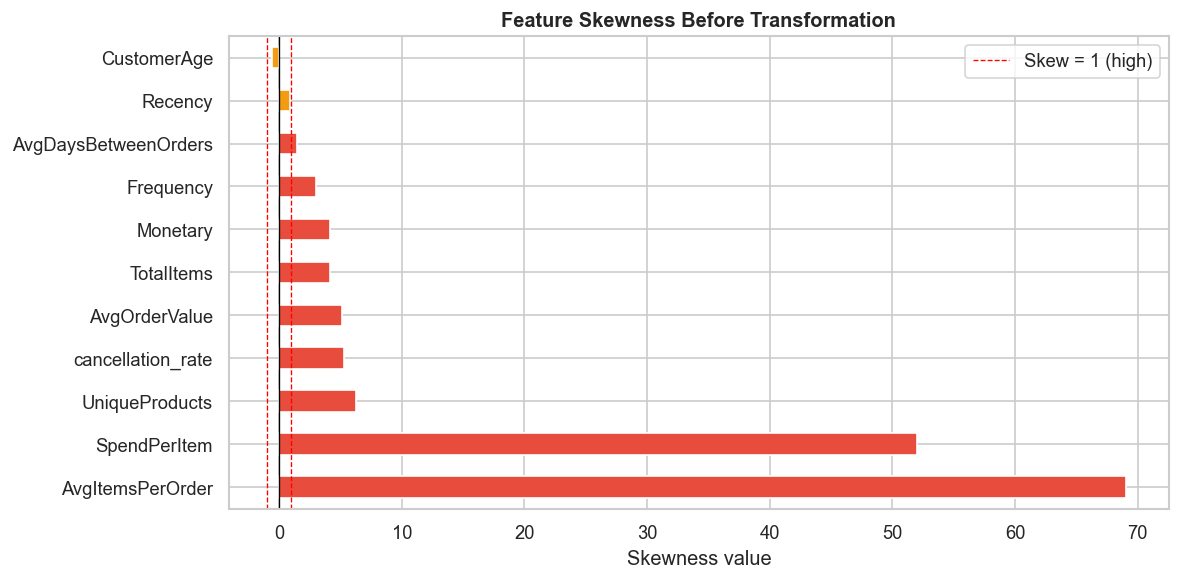

✅ Saved: skewness_before.png


In [4]:
# Skewness analysis — justify log transformation

skewness = X.skew().sort_values(ascending=False)

print("Feature Skewness (before transformation)")
print("=" * 40)
for feat, skew in skewness.items():
    flag = "⚠️  highly skewed" if abs(skew) > 1 else ("📊 moderate" if abs(skew) > 0.5 else "✅ normal")
    print(f"  {feat:<28} {skew:>8.2f}  {flag}")

# Visualize skewness
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if abs(s) > 1 else '#f39c12' if abs(s) > 0.5 else '#2ecc71'
          for s in skewness]
skewness.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0,  color='black', linewidth=0.8)
ax.axvline(1,  color='red',   linewidth=0.8, linestyle='--', label='Skew = 1 (high)')
ax.axvline(-1, color='red',   linewidth=0.8, linestyle='--')
ax.set_title('Feature Skewness Before Transformation', fontweight='bold')
ax.set_xlabel('Skewness value')
ax.legend()
plt.tight_layout()
plt.savefig('../results/cluster_plots/skewness_before.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: skewness_before.png")

Applying log1p to 9 highly skewed features:
  • Frequency  (skew before: 3.02)  →  skew after: 0.82
  • Monetary  (skew before: 4.10)  →  skew after: 0.12
  • AvgOrderValue  (skew before: 5.11)  →  skew after: 0.99
  • TotalItems  (skew before: 4.16)  →  skew after: -0.26
  • AvgItemsPerOrder  (skew before: 69.05)  →  skew after: 1.52
  • UniqueProducts  (skew before: 6.22)  →  skew after: -0.28
  • AvgDaysBetweenOrders  (skew before: 1.44)  →  skew after: -0.31
  • SpendPerItem  (skew before: 51.99)  →  skew after: 6.59
  • cancellation_rate  (skew before: 5.32)  →  skew after: 4.57


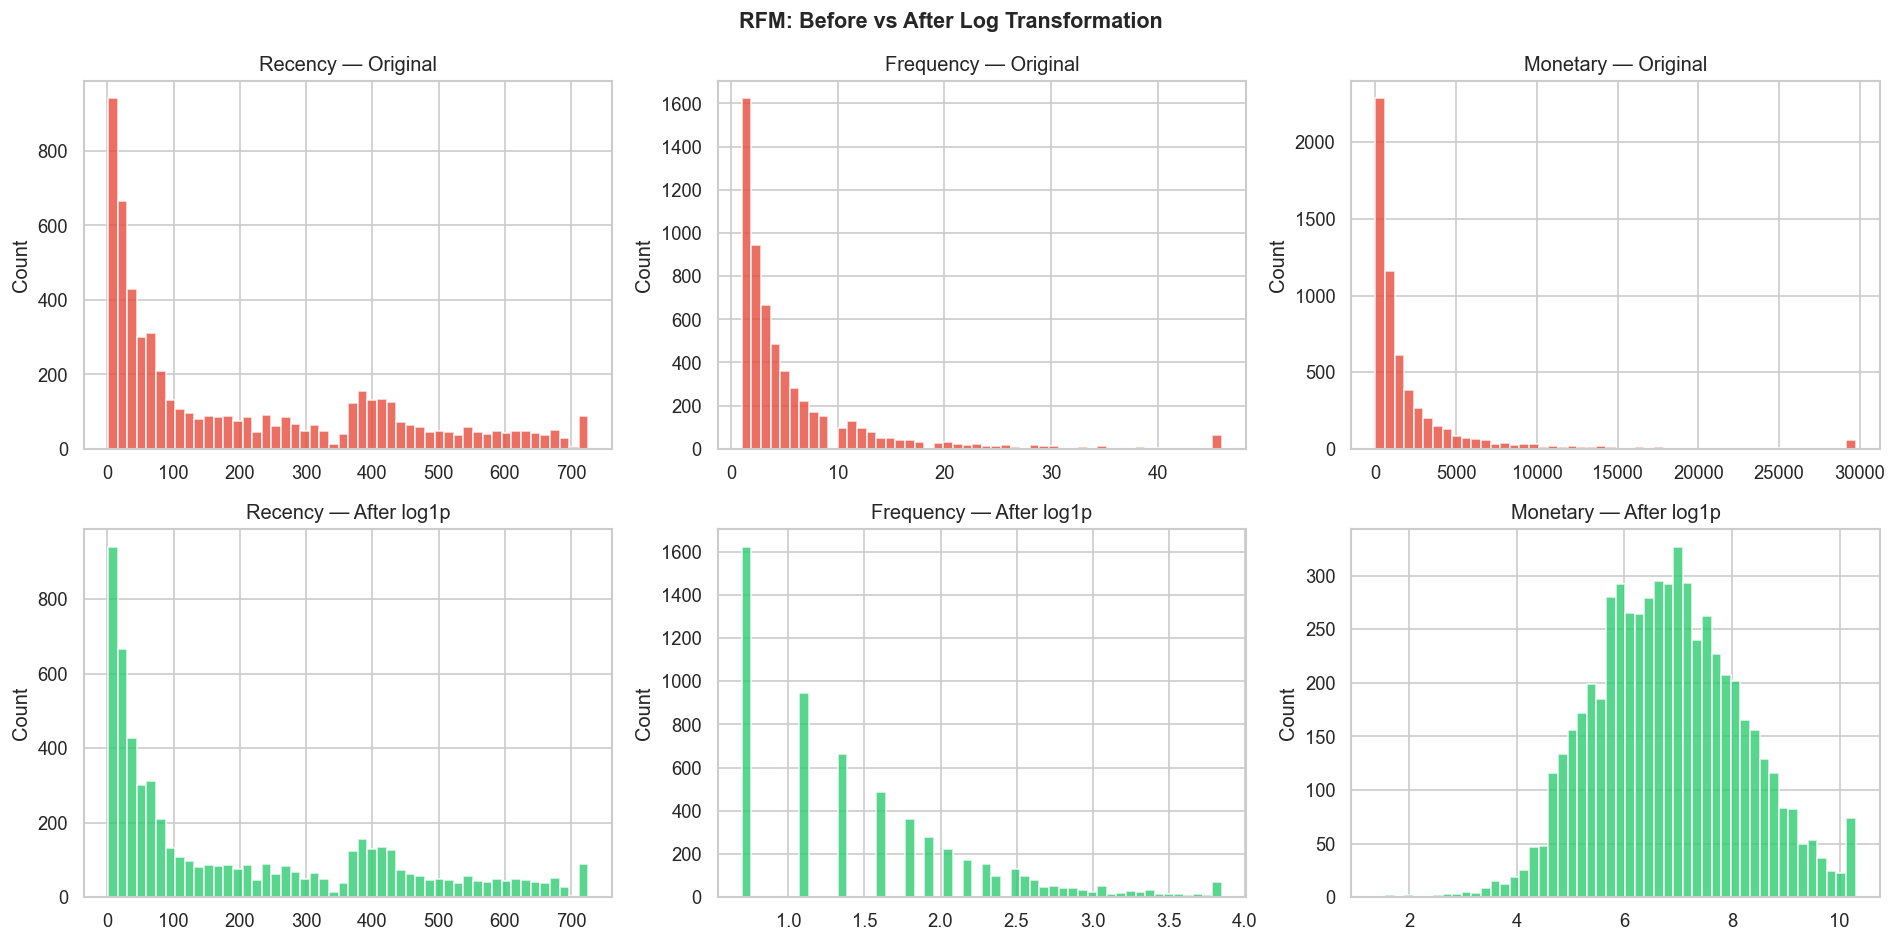

✅ Saved: log_transform_comparison.png


In [5]:
# Apply log1p transformation to skewed features
# log1p(x) = log(x+1) — safe for zero values

# Features that need log transformation (skew > 1)
LOG_FEATURES = [f for f in FEATURES if abs(X[f].skew()) > 1]

print(f"Applying log1p to {len(LOG_FEATURES)} highly skewed features:")
for f in LOG_FEATURES:
    print(f"  • {f}  (skew before: {X[f].skew():.2f})", end='')
    X[f] = np.log1p(X[f])
    print(f"  →  skew after: {X[f].skew():.2f}")

# Visualize RFM before vs after (side by side)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
rfm = ['Recency', 'Frequency', 'Monetary']

df_raw = pd.read_csv('../data/processed/customer_features.csv')

for i, col in enumerate(rfm):
    # Before
    axes[0][i].hist(df_raw[col], bins=50, color='#e74c3c',
                    edgecolor='white', alpha=0.8)
    axes[0][i].set_title(f'{col} — Original')
    axes[0][i].set_ylabel('Count')

    # After
    axes[1][i].hist(X[col], bins=50, color='#2ecc71',
                    edgecolor='white', alpha=0.8)
    axes[1][i].set_title(f'{col} — After log1p')
    axes[1][i].set_ylabel('Count')

plt.suptitle('RFM: Before vs After Log Transformation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cluster_plots/log_transform_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: log_transform_comparison.png")

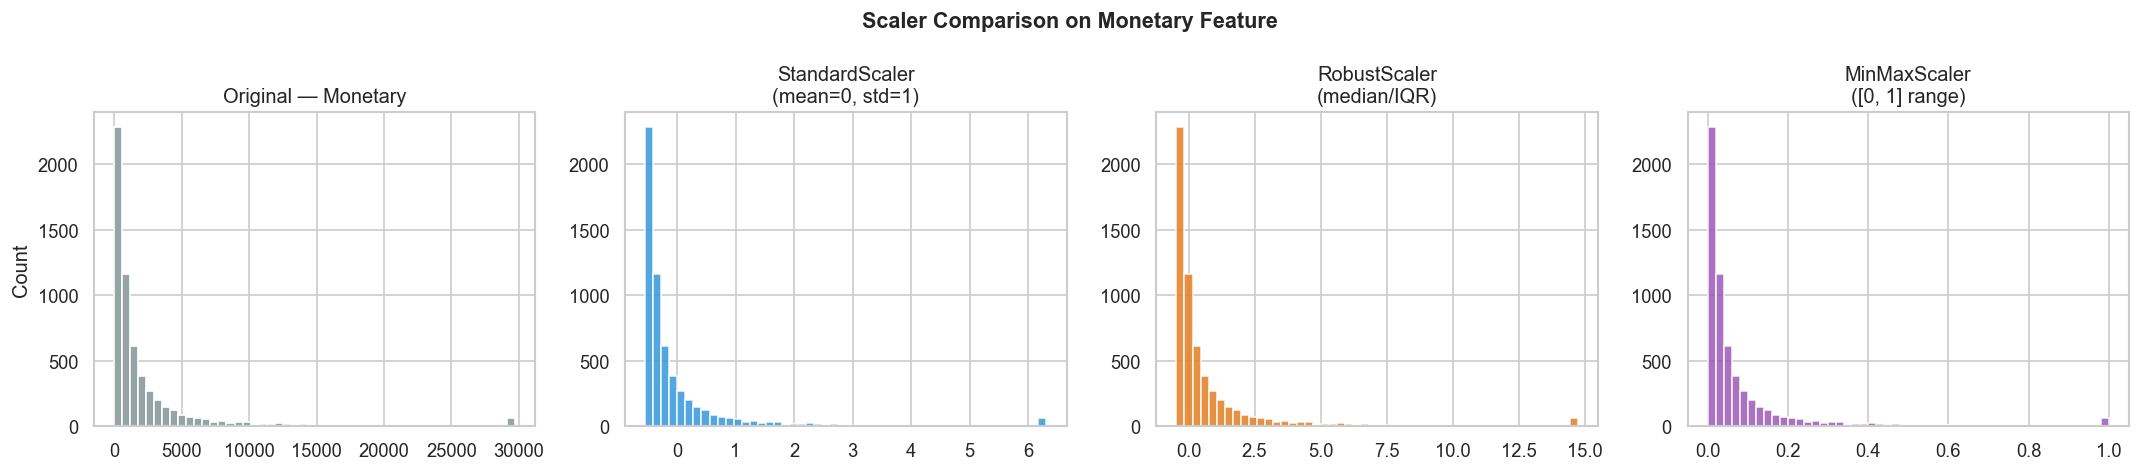

✅ Saved: scaler_comparison.png

SCALER DECISION:
  ✅ RobustScaler chosen because:
     • Uses median and IQR — not affected by remaining outliers
     • Better than StandardScaler when data has heavy tails
     • Better than MinMaxScaler which compresses all values into [0,1]
       and is sensitive to extreme values
     • Ideal for customer spend data which is always right-skewed



In [6]:
# Compare StandardScaler vs RobustScaler vs MinMaxScaler
# This justifies WHY we pick RobustScaler for clustering

sample_col = 'Monetary'
raw_vals = df_raw[sample_col].values.reshape(-1, 1)

scalers = {
    'StandardScaler\n(mean=0, std=1)':  StandardScaler(),
    'RobustScaler\n(median/IQR)':       RobustScaler(),
    'MinMaxScaler\n([0, 1] range)':     MinMaxScaler(),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].hist(raw_vals, bins=50, color='#95a5a6', edgecolor='white')
axes[0].set_title('Original — Monetary')
axes[0].set_ylabel('Count')

colors_s = ['#3498db', '#e67e22', '#9b59b6']
for ax, (name, scaler), color in zip(axes[1:], scalers.items(), colors_s):
    scaled = scaler.fit_transform(raw_vals)
    ax.hist(scaled, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(name)

plt.suptitle('Scaler Comparison on Monetary Feature',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cluster_plots/scaler_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: scaler_comparison.png")

print("""
SCALER DECISION:
  ✅ RobustScaler chosen because:
     • Uses median and IQR — not affected by remaining outliers
     • Better than StandardScaler when data has heavy tails
     • Better than MinMaxScaler which compresses all values into [0,1]
       and is sensitive to extreme values
     • Ideal for customer spend data which is always right-skewed
""")

In [7]:
# Apply RobustScaler to all features

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)

print("Scaling complete using RobustScaler")
print(f"\nScaled feature matrix shape: {X_scaled_df.shape}")
print("\nSample statistics after scaling (should be centred around 0):")
print(X_scaled_df.describe().T[['mean','std','min','50%','max']].round(3))

Scaling complete using RobustScaler

Scaled feature matrix shape: (5878, 11)

Sample statistics after scaling (should be centred around 0):
                       mean    std    min  50%     max
Recency               0.297  0.591 -0.268  0.0   1.780
Frequency             0.114  0.569 -0.500  0.0   1.777
Monetary              0.014  0.722 -2.877 -0.0   1.854
AvgOrderValue         0.055  1.136 -2.556  0.0   4.248
TotalItems            0.000  0.755 -2.787  0.0   1.807
AvgItemsPerOrder      0.033  1.023 -2.004  0.0   9.427
UniqueProducts       -0.042  0.739 -1.902  0.0   2.436
CustomerAge          -0.156  0.628 -1.490  0.0   0.589
AvgDaysBetweenOrders -0.016  0.713 -2.780  0.0   1.262
SpendPerItem          0.157  1.447 -2.892  0.0  25.677
cancellation_rate     1.009  2.376  0.000  0.0  22.850


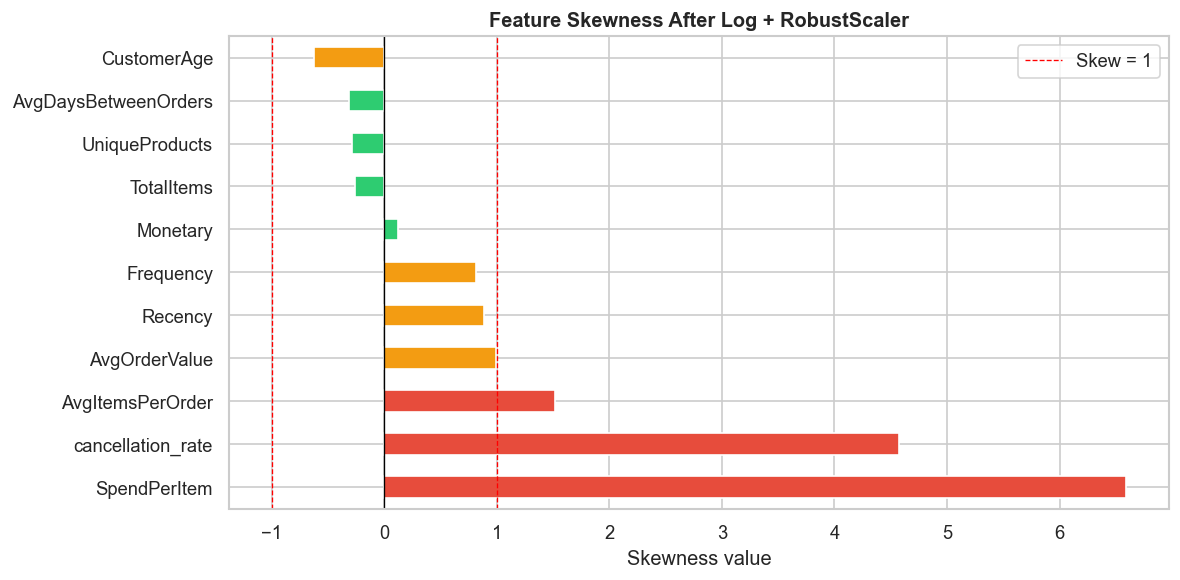

✅ Saved: skewness_after.png


In [8]:
# Confirm skewness improved after all transformations

skew_after = X_scaled_df.skew().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors2 = ['#e74c3c' if abs(s) > 1 else '#f39c12' if abs(s) > 0.5 else '#2ecc71'
           for s in skew_after]
skew_after.plot(kind='barh', ax=ax, color=colors2, edgecolor='white')
ax.axvline(0,  color='black', linewidth=0.8)
ax.axvline(1,  color='red',   linewidth=0.8, linestyle='--', label='Skew = 1')
ax.axvline(-1, color='red',   linewidth=0.8, linestyle='--')
ax.set_title('Feature Skewness After Log + RobustScaler', fontweight='bold')
ax.set_xlabel('Skewness value')
ax.legend()
plt.tight_layout()
plt.savefig('../results/cluster_plots/skewness_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: skewness_after.png")

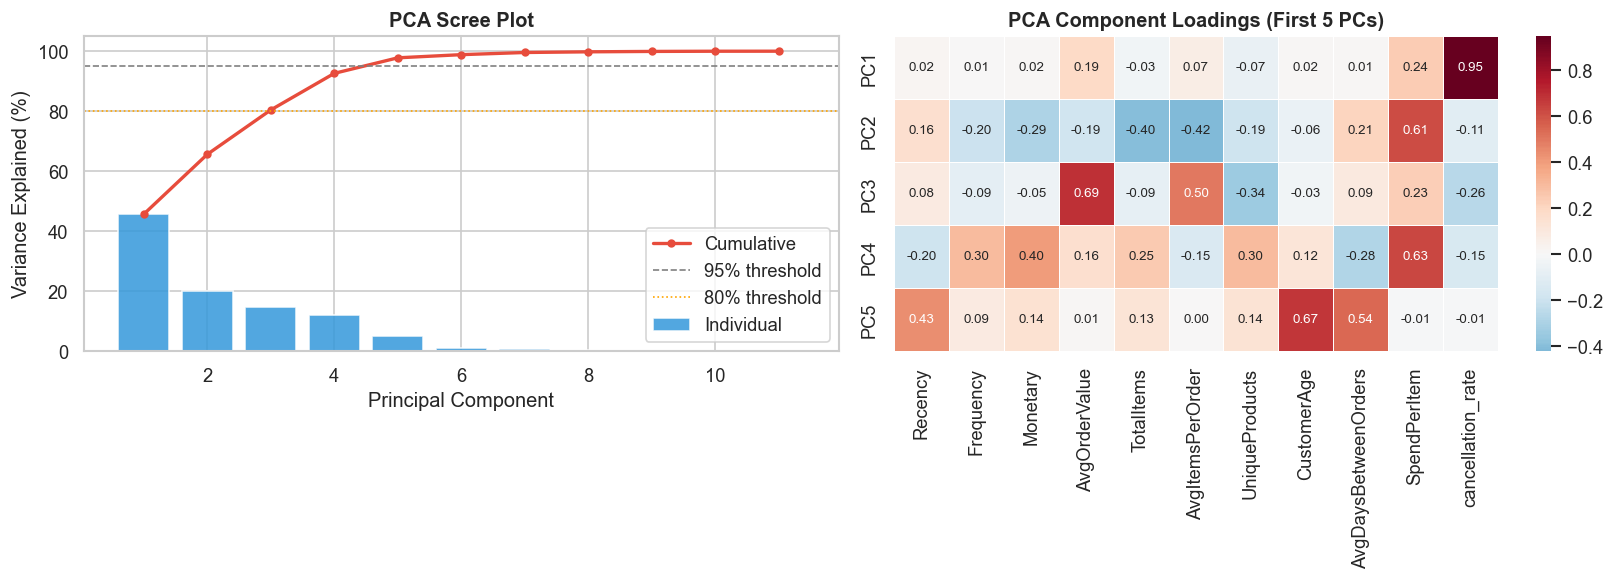

Components for 80% variance: 3
Components for 95% variance: 5
Total features: 11

✅ Saved: pca_variance_explained.png


In [9]:
# PCA — how many components explain 95% variance?

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled_df)

explained       = pca_full.explained_variance_ratio_
cumulative_var  = np.cumsum(explained)

# Find components needed for 95% variance
n_95 = np.argmax(cumulative_var >= 0.95) + 1
n_80 = np.argmax(cumulative_var >= 0.80) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained)+1), explained * 100,
            color='#3498db', edgecolor='white', alpha=0.85, label='Individual')
axes[0].plot(range(1, len(explained)+1), cumulative_var * 100,
             color='#e74c3c', linewidth=2, marker='o', markersize=4,
             label='Cumulative')
axes[0].axhline(95, color='gray', linestyle='--', linewidth=1, label='95% threshold')
axes[0].axhline(80, color='orange', linestyle=':', linewidth=1, label='80% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('PCA Scree Plot', fontweight='bold')
axes[0].legend()

# Component loadings heatmap (first 5 PCs)
loadings = pd.DataFrame(
    pca_full.components_[:5],
    columns=FEATURES,
    index=[f'PC{i+1}' for i in range(5)]
)
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('PCA Component Loadings (First 5 PCs)', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/pca_outputs/pca_variance_explained.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Components for 80% variance: {n_80}")
print(f"Components for 95% variance: {n_95}")
print(f"Total features: {len(FEATURES)}")
print(f"\n✅ Saved: pca_variance_explained.png")

2D PCA shape  : (5878, 2)  — variance explained: 65.6%
3D PCA shape  : (5878, 3)  — variance explained: 80.4%
95% PCA shape : (5878, 5) — variance explained: 97.8%


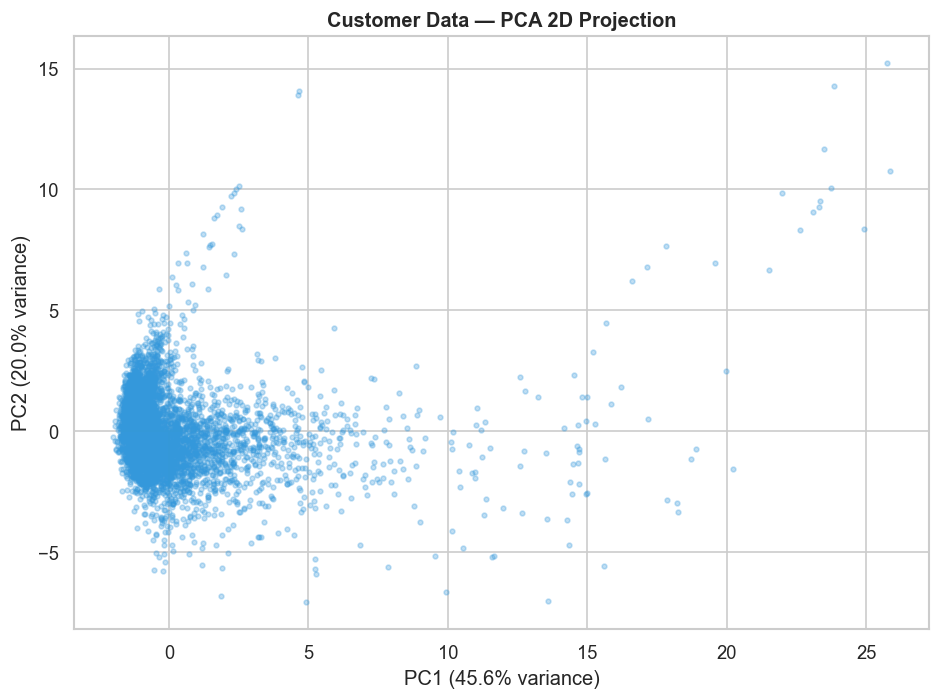

✅ Saved: pca_2d_preview.png


In [10]:
# Fit PCA for 2D and 3D visualization

# 2D PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled_df)

# 3D PCA
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled_df)

# Full PCA for 95% variance (used in clustering)
pca_95 = PCA(n_components=n_95, random_state=42)
X_pca_95 = pca_95.fit_transform(X_scaled_df)

print(f"2D PCA shape  : {X_pca_2d.shape}  — variance explained: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"3D PCA shape  : {X_pca_3d.shape}  — variance explained: {pca_3d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"95% PCA shape : {X_pca_95.shape} — variance explained: {pca_95.explained_variance_ratio_.sum()*100:.1f}%")

# Quick 2D scatter preview
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
           alpha=0.3, s=8, color='#3498db')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Customer Data — PCA 2D Projection', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/pca_outputs/pca_2d_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: pca_2d_preview.png")

In [11]:
# Save all versions for use in clustering notebooks

# 1. Scaled full features (for clustering)
X_scaled_df['Customer ID'] = customer_ids.values
X_scaled_df.to_csv('../data/processed/features_scaled.csv', index=False)

# 2. PCA 2D (for visualization)
pca_2d_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_2d_df['Customer ID'] = customer_ids.values
pca_2d_df.to_csv('../data/processed/features_pca_2d.csv', index=False)

# 3. PCA 3D (for 3D visualization)
pca_3d_df = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_3d_df['Customer ID'] = customer_ids.values
pca_3d_df.to_csv('../data/processed/features_pca_3d.csv', index=False)

# 4. PCA 95% variance (for clean clustering input)
pca_95_cols = [f'PC{i+1}' for i in range(n_95)]
pca_95_df = pd.DataFrame(X_pca_95, columns=pca_95_cols)
pca_95_df['Customer ID'] = customer_ids.values
pca_95_df.to_csv('../data/processed/features_pca_95.csv', index=False)

print("✅ All engineered datasets saved:")
print("   • data/processed/features_scaled.csv      ← full scaled features")
print("   • data/processed/features_pca_2d.csv      ← 2D for visualization")
print("   • data/processed/features_pca_3d.csv      ← 3D for visualization")
print("   • data/processed/features_pca_95.csv      ← 95% variance PCA")

✅ All engineered datasets saved:
   • data/processed/features_scaled.csv      ← full scaled features
   • data/processed/features_pca_2d.csv      ← 2D for visualization
   • data/processed/features_pca_3d.csv      ← 3D for visualization
   • data/processed/features_pca_95.csv      ← 95% variance PCA


In [12]:
# Feature engineering summary

print("=" * 55)
print("  FEATURE ENGINEERING COMPLETE — SUMMARY")
print("=" * 55)
print(f"  Input features             : {len(FEATURES)}")
print(f"  Log-transformed features   : {len(LOG_FEATURES)}")
print(f"  Scaler used                : RobustScaler")
print(f"  PCA components (95% var)   : {n_95}")
print(f"  PCA components (80% var)   : {n_80}")
print()
print("  Saved datasets:")
print("    ✅ features_scaled.csv")
print("    ✅ features_pca_2d.csv")
print("    ✅ features_pca_3d.csv")
print("    ✅ features_pca_95.csv")
print()
print("  Plots saved:")
print("    ✅ skewness_before.png")
print("    ✅ log_transform_comparison.png")
print("    ✅ scaler_comparison.png")
print("    ✅ skewness_after.png")
print("    ✅ pca_variance_explained.png")
print("    ✅ pca_2d_preview.png")
print("=" * 55)
print("\n✅ Ready for Notebook 04 — Clustering Models")

  FEATURE ENGINEERING COMPLETE — SUMMARY
  Input features             : 11
  Log-transformed features   : 9
  Scaler used                : RobustScaler
  PCA components (95% var)   : 5
  PCA components (80% var)   : 3

  Saved datasets:
    ✅ features_scaled.csv
    ✅ features_pca_2d.csv
    ✅ features_pca_3d.csv
    ✅ features_pca_95.csv

  Plots saved:
    ✅ skewness_before.png
    ✅ log_transform_comparison.png
    ✅ scaler_comparison.png
    ✅ skewness_after.png
    ✅ pca_variance_explained.png
    ✅ pca_2d_preview.png

✅ Ready for Notebook 04 — Clustering Models
